# Manual Classification Metrics
Evaluates the algorithmic `valid_flag` against manual labels.

In [4]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [5]:
MANUAL_LABELS_PATH = "../../results/summary/manual_labels_v3.csv"

df = pd.read_csv(MANUAL_LABELS_PATH)
df = df[df["manual_label"] != "skip"].copy()

print(f"Total samples (excl. skip): {len(df)}")
print()
print("Manual label distribution:")
print(df["manual_label"].value_counts())
print()
print("Algo label distribution:")
print(df["valid_flag"].value_counts())

Total samples (excl. skip): 100

Manual label distribution:
manual_label
unchanged     22
cleaned       18
fixed_dict    17
empty         16
refused       16
invalid       11
Name: count, dtype: int64

Algo label distribution:
valid_flag
cleaned       19
unchanged     17
empty         16
invalid       16
refused       16
fixed_dict    16
Name: count, dtype: int64


In [6]:
y_true = df["manual_label"]
y_pred = df["valid_flag"]
labels = sorted(set(y_true) | set(y_pred))

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0)
recall    = recall_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0)
f1        = f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0)

print(f"Accuracy:             {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall    (weighted): {recall:.4f}")
print(f"F1-score  (weighted): {f1:.4f}")

Accuracy:             0.9000
Precision (weighted): 0.9203
Recall    (weighted): 0.9000
F1-score  (weighted): 0.9038


In [7]:
print("Per-class report (manual = truth, algo = prediction):")
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

Per-class report (manual = truth, algo = prediction):
              precision    recall  f1-score   support

     cleaned       0.84      0.89      0.86        18
       empty       1.00      1.00      1.00        16
  fixed_dict       1.00      0.94      0.97        17
     invalid       0.62      0.91      0.74        11
     refused       0.94      0.94      0.94        16
   unchanged       1.00      0.77      0.87        22

    accuracy                           0.90       100
   macro avg       0.90      0.91      0.90       100
weighted avg       0.92      0.90      0.90       100



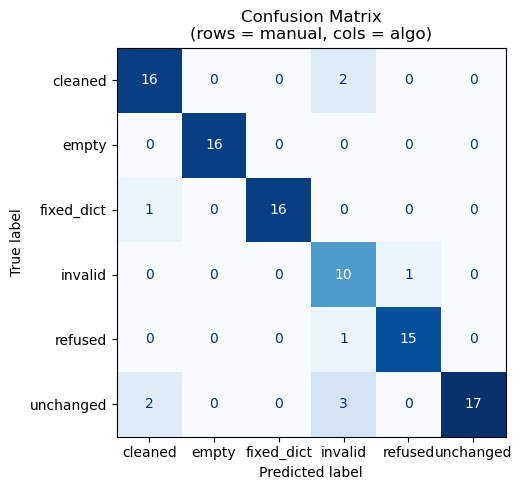

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_true, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix\n(rows = manual, cols = algo)")
plt.tight_layout()
plt.show()

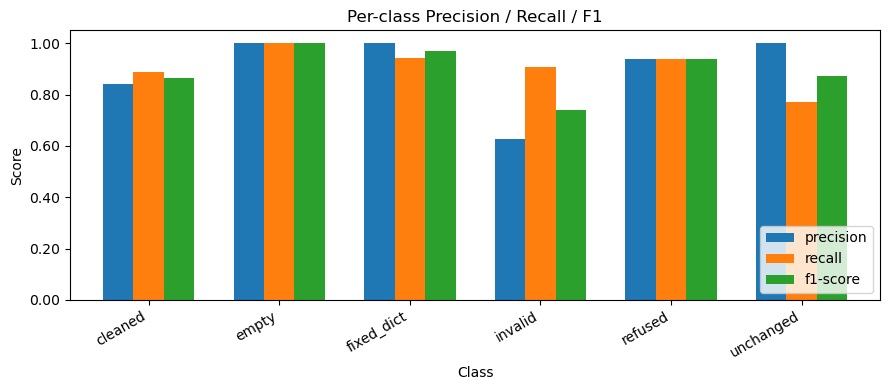

In [9]:
report_df = pd.DataFrame(
    classification_report(y_true, y_pred, labels=labels, zero_division=0, output_dict=True)
).T.drop(index=["accuracy"], errors="ignore")

per_class = report_df.loc[labels, ["precision", "recall", "f1-score"]]

fig, ax = plt.subplots(figsize=(9, 4))
per_class.plot(kind="bar", ax=ax, width=0.7)
ax.set_title("Per-class Precision / Recall / F1")
ax.set_xlabel("Class")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.legend(loc="lower right")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Summary Statistics (Full Dataset)
Counts and distributions from the complete `summary.csv` across all models and experiments.

In [10]:
SUMMARY_PATH = "../../results/summary/summary.csv"

summary = pd.read_csv(SUMMARY_PATH, low_memory=False)

total    = len(summary)
n_models = summary["model"].nunique()
n_roles  = summary["role"].nunique()
n_tasks  = summary["task"].nunique()

print(f"Total rows:   {total:,}")
print(f"Models:       {n_models}")
print(f"Roles:        {n_roles}")
print(f"Tasks:        {n_tasks}")
print()

flag_counts = summary["valid_flag"].value_counts()
flag_pct    = (flag_counts / total * 100).round(2)
flag_df     = pd.DataFrame({"count": flag_counts, "pct": flag_pct})
flag_df.index.name = "valid_flag"
print("valid_flag distribution (all data):")
print(flag_df.to_string())

Total rows:   928,800
Models:       43
Roles:        6
Tasks:        6

valid_flag distribution (all data):
             count    pct
valid_flag               
cleaned     453738  48.85
unchanged   330759  35.61
invalid      89852   9.67
refused      46317   4.99
empty         7062   0.76
fixed_dict    1072   0.12


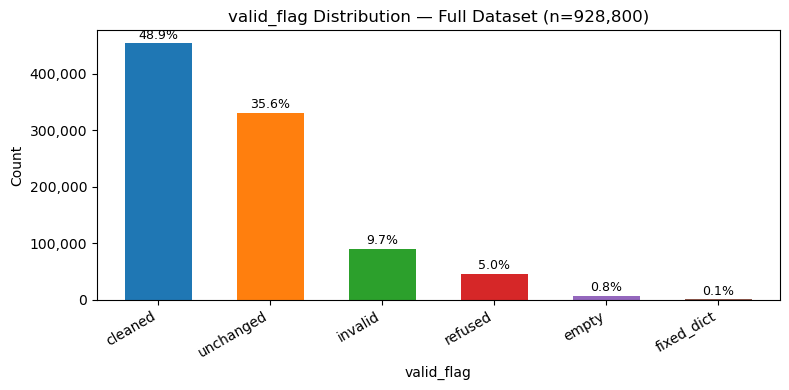

In [11]:
# Bar chart: global valid_flag distribution
fig, ax = plt.subplots(figsize=(8, 4))
colors = plt.cm.tab10.colors

flag_counts.plot(kind="bar", ax=ax, color=colors[:len(flag_counts)], width=0.6)
ax.set_title(f"valid_flag Distribution — Full Dataset (n={total:,})")
ax.set_xlabel("valid_flag")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, pct in zip(ax.patches, flag_pct):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total * 0.003,
        f"{pct:.1f}%",
        ha="center", va="bottom", fontsize=9,
    )
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

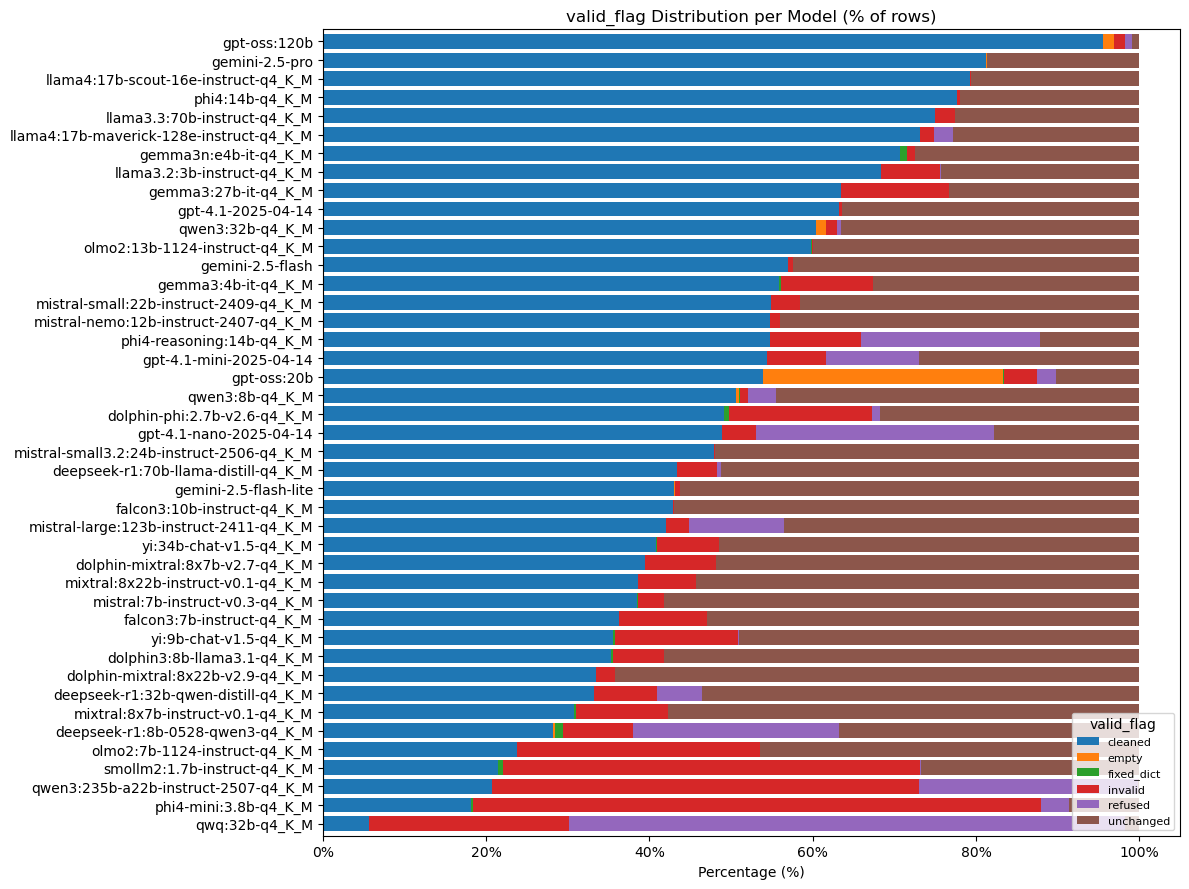

In [12]:
# Per-model valid_flag breakdown (stacked 100% bar)
model_flag = (
    summary.groupby(["model", "valid_flag"])
    .size()
    .unstack(fill_value=0)
)
model_flag_pct = model_flag.div(model_flag.sum(axis=1), axis=0) * 100
model_flag_pct = model_flag_pct.sort_values("cleaned", ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))
model_flag_pct.plot(kind="barh", stacked=True, ax=ax, width=0.8)
ax.set_title("valid_flag Distribution per Model (% of rows)")
ax.set_xlabel("Percentage (%)")
ax.set_ylabel("")
ax.legend(loc="lower right", title="valid_flag", fontsize=8)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
plt.tight_layout()
plt.show()

In [13]:
# Per-model absolute counts + valid_pct (cleaned + unchanged + fixed_dict)
valid_cats = [c for c in ["cleaned", "unchanged", "fixed_dict"] if c in model_flag.columns]
all_cats   = [c for c in ["cleaned", "unchanged", "fixed_dict", "invalid", "refused", "empty"] if c in model_flag.columns]
model_flag["valid_total"] = model_flag[valid_cats].sum(axis=1)
model_flag["total"]       = model_flag[all_cats].sum(axis=1)
model_flag["valid_pct"]   = (model_flag["valid_total"] / model_flag["total"] * 100).round(1)

display_cols = all_cats + ["valid_total", "valid_pct"]
print(model_flag[display_cols].sort_values("valid_pct", ascending=False).to_string())

valid_flag                                 cleaned  unchanged  fixed_dict  invalid  refused  empty  valid_total  valid_pct
model                                                                                                                     
falcon3:10b-instruct-q4_K_M                   9274      12312           1       12        1      0        21587       99.9
mistral-small3.2:24b-instruct-2506-q4_K_M    10340      11233           0       27        0      0        21573       99.9
gemini-2.5-pro                               17546       4016           1       10        0     27        21563       99.8
olmo2:13b-1124-instruct-q4_K_M               12924       8632           6       35        3      0        21562       99.8
llama4:17b-scout-16e-instruct-q4_K_M         17110       4451           5       34        0      0        21566       99.8
gpt-4.1-2025-04-14                           13649       7859           0       83        9      0        21508       99.6
phi4:14b-q4_K_M 